# leftDRGcut Calcium Imaging Explorer

Reusable toolkit for loading, processing, and visualizing the raw `.npy`
acquisition data in this folder's `raw/` subfolder. Run it top-to-bottom with
no edits, then tweak the **Config** cell to point at a different recording or
channel.

## What's in this folder

Raw data lives in `raw/`, exported from a 3i SlideBook acquisition (`leftDRGcut`, channel 0 = GFP/GCaMP):

| Files | Shape | dtype | Meaning |
|---|---|---|---|
| `ImageData_Ch0_TP*.npy` | `(1, 1024, 1376)` | `uint16` | one raw frame per timepoint |
| `HistogramData_Ch0_TP*.npy` | `(1, 16384)` | `uint32` | pixel-intensity histogram for that same frame (bin width = 4 intensity units — verified below to exactly match `np.histogram(frame, bins=16384, range=(0, 65536))`) |
| `ElapsedTimes.yaml` | — | — | acquisition time (ms) for every timepoint |
| `*Record.yaml` / `*PositionData.yaml` | — | — | SlideBook acquisition metadata (channel, stage, annotations) |

There are 3220 timepoints acquired at roughly 10 Hz (~100 ms/frame) over ~5.4 minutes.
The full image stack is ~8.4 GB, so this notebook **streams frames one at a time**
instead of loading everything into RAM, and caches expensive per-frame results to
`analysis_cache/` (next to this notebook, separate from `raw/`) as Parquet/`.npy`
(via Polars) so re-running later is instant.

**Kernel:** select the `Cajal` conda environment as the Jupyter kernel for this
notebook (VS Code: "Select Kernel" → Cajal). It already has `polars`, `numpy`, `matplotlib`, `ipywidgets`, `pyyaml`, `tifffile`,
and `tqdm`. Section 9.5 launches model inference with the separate `CASCADE`
environment, so the image-processing portion remains on the `Cajal` kernel.


In [12]:
from __future__ import annotations

import hashlib
import json
import re
from pathlib import Path

import ipywidgets as widgets
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import tifffile
import yaml
from matplotlib.path import Path as MplPath
from scipy import ndimage
from tqdm.auto import tqdm

%matplotlib inline


## Config

Everything below only needs to be edited here. `DATA_DIR` can point at any other
SlideBook export folder with the same file naming convention, and `CHANNEL`
switches which channel's `ImageData` / `HistogramData` files are read.


In [13]:
DATA_DIR = Path("/Users/samsonho/KSL/leftDRGcut/raw")   # raw ImageData/HistogramData/*.yaml
CHANNEL = 0                                              # which Ch<N> to analyze
CACHE_DIR = Path("/Users/samsonho/KSL/leftDRGcut/analysis_cache")  # this notebook's own outputs
CACHE_DIR.mkdir(exist_ok=True)

# ROI selection: the widget in section 8 defaults to the supplied label image.
ROI_SOURCE_DEFAULT = "tiff"  # "tiff" | "auto"
ROI_LABEL_PATH = Path("/Users/samsonho/KSL/leftDRGcut/_labels/Debi_DRG_ROI.tiff")

IMAGE_GLOB = f"ImageData_Ch{CHANNEL}_TP*.npy"
HIST_GLOB = f"HistogramData_Ch{CHANNEL}_TP*.npy"
TP_PATTERN = re.compile(r"_TP(\d+)\.npy$")

# --- preprocessing (applied to every frame before detection & trace extraction) ---
DENOISE_METHOD = "gat_nlm"   # "gaussian" (sigma below) | "gaussian2" (sigma=2) | "gat_nlm"
#   "gat_nlm" = generalised-Anscombe (Poisson) + NL-means: best low-light denoise, but
#   ~0.5 s/frame, so its fully-preprocessed frames are cached to
#   analysis_cache/denoised_gat_nlm_ch<N>/ (~9 GB for 3220 frames) and reused by sections 8/9.
DENOISE_SIGMA = 1.0        # Gaussian sigma in px (used by "gaussian"); set 0 to disable
BACKGROUND_PERCENTILE = 3  # subtract this per-frame intensity percentile as a flat offset


## 1. Build a file index

Every timepoint has a matching image file and histogram file. We index them once
into a tidy Polars `DataFrame` (sorted by timepoint) so the rest of the notebook
can look up a path by timepoint instead of re-globbing the directory.


In [14]:
def _index_files(data_dir: Path, glob_pattern: str, column_name: str) -> pl.DataFrame:
    rows = []
    for path in data_dir.glob(glob_pattern):
        match = TP_PATTERN.search(path.name)
        if match:
            rows.append({"timepoint": int(match.group(1)), column_name: str(path)})
    if not rows:
        raise FileNotFoundError(
            f"no files matched {data_dir / glob_pattern} -- check DATA_DIR and CHANNEL "
            "in the Config cell, and re-run from the top after changing them "
            "(defaults are bound when a function is defined, not when it's called)"
        )
    return pl.DataFrame(rows)


def build_file_index(data_dir: Path = DATA_DIR) -> pl.DataFrame:
    '''One row per timepoint, with paths to its image and histogram files.'''
    images = _index_files(data_dir, IMAGE_GLOB, "image_path")
    hists = _index_files(data_dir, HIST_GLOB, "hist_path")
    return images.join(hists, on="timepoint", how="left").sort("timepoint")


file_index = build_file_index()
print(f"{file_index.height} timepoints found for channel {CHANNEL}")
file_index.head()


3220 timepoints found for channel 0


timepoint,image_path,hist_path
i64,str,str
0,"""/Users/samsonho/KSL/leftDRGcut…","""/Users/samsonho/KSL/leftDRGcut…"
1,"""/Users/samsonho/KSL/leftDRGcut…","""/Users/samsonho/KSL/leftDRGcut…"
2,"""/Users/samsonho/KSL/leftDRGcut…","""/Users/samsonho/KSL/leftDRGcut…"
3,"""/Users/samsonho/KSL/leftDRGcut…","""/Users/samsonho/KSL/leftDRGcut…"
4,"""/Users/samsonho/KSL/leftDRGcut…","""/Users/samsonho/KSL/leftDRGcut…"


## 2. Attach acquisition timing

`ElapsedTimes.yaml` stores the real acquisition time (ms) of every timepoint. We
parse it once and join it onto the file index so plots can use real seconds
instead of frame index.


In [15]:
def load_elapsed_times(data_dir: Path = DATA_DIR) -> pl.DataFrame:
    '''Returns a (timepoint, elapsed_ms, elapsed_s) DataFrame from ElapsedTimes.yaml.'''
    with open(data_dir / "ElapsedTimes.yaml") as f:
        raw = yaml.safe_load(f)["theElapsedTimes"]
    elapsed_ms = raw[1:]  # raw[0] is just the declared count, not a timepoint
    return pl.DataFrame({
        "timepoint": range(len(elapsed_ms)),
        "elapsed_ms": elapsed_ms,
    }).with_columns((pl.col("elapsed_ms") / 1000).alias("elapsed_s"))


file_index = file_index.join(load_elapsed_times(), on="timepoint", how="left")
duration_s = file_index["elapsed_s"].max()
print(f"recording duration: {duration_s:.1f} s (~{duration_s / 60:.1f} min), "
      f"~{file_index.height / duration_s:.1f} Hz")
file_index.head()


recording duration: 322.2 s (~5.4 min), ~10.0 Hz


timepoint,image_path,hist_path,elapsed_ms,elapsed_s
i64,str,str,i64,f64
0,"""/Users/samsonho/KSL/leftDRGcut…","""/Users/samsonho/KSL/leftDRGcut…",0,0.0
1,"""/Users/samsonho/KSL/leftDRGcut…","""/Users/samsonho/KSL/leftDRGcut…",99,0.099
2,"""/Users/samsonho/KSL/leftDRGcut…","""/Users/samsonho/KSL/leftDRGcut…",199,0.199
3,"""/Users/samsonho/KSL/leftDRGcut…","""/Users/samsonho/KSL/leftDRGcut…",299,0.299
4,"""/Users/samsonho/KSL/leftDRGcut…","""/Users/samsonho/KSL/leftDRGcut…",399,0.399


## 3. Frame loaders & preprocessing

Two ways to get a frame:

- `load_frame` — the **raw** `uint16` frame, untouched. Used by the raw-data QC
  views (histogram in §4, browser in §5) that need to match the acquisition
  exactly.
- `load_processed_frame` — the frame that **analysis** runs on, after two
  preprocessing steps set in the Config cell:
  1. **Gaussian denoise** — spatial smoothing (`DENOISE_SIGMA`) that averages
     out per-pixel shot noise while keeping cell-scale structure (drops a flat
     background patch's std by ~30% at σ=1 here).
  2. **Background subtraction** — subtract the `BACKGROUND_PERCENTILE`-th
     intensity of that frame as a single flat offset (a linear shift). The 3rd
     percentile (~720 here) is essentially the camera dark/background floor, so
     this pins the noise floor near 0 without changing any pixel-to-pixel
     contrast.

Detection (§8) and trace extraction (§9) both use `load_processed_frame`, so
everything downstream sees denoised, background-subtracted data.


raw frame: (1024, 1376) uint16 range: 384 - 1494
histogram: (16384,) uint32 total counts: 1409024


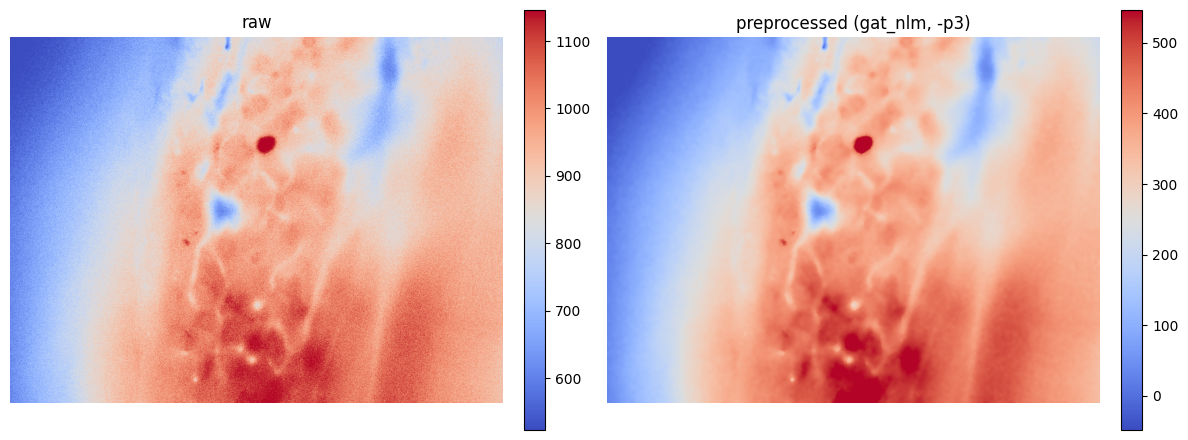

In [16]:
def load_frame(timepoint: int, index: pl.DataFrame = file_index) -> np.ndarray:
    '''Load one raw (1024, 1376) uint16 frame, untouched.'''
    path = index.filter(pl.col("timepoint") == timepoint)["image_path"].item()
    return np.load(path).squeeze(axis=0)


def load_histogram(timepoint: int, index: pl.DataFrame = file_index) -> np.ndarray:
    '''Load the matching (16384,) precomputed intensity histogram (bin width = 4).'''
    path = index.filter(pl.col("timepoint") == timepoint)["hist_path"].item()
    return np.load(path).squeeze(axis=0)


# --- camera calibration for Poisson-aware denoising -------------------------------
_PTC_MEMO: dict = {}


def camera_gain_offset(index: pl.DataFrame = file_index, n_block: int = 60) -> tuple[float, float]:
    '''Camera gain (ADU/e-) and offset (ADU) from the photon-transfer curve: shot-noise
    variance is linear in mean intensity, Var = gain*(mean - offset). Fitted once from a
    consecutive block, cached + memoised. Only "gat_nlm" needs it.'''
    if CHANNEL in _PTC_MEMO:
        return _PTC_MEMO[CHANNEL]
    cache_path = CACHE_DIR / f"camera_ptc_ch{CHANNEL}.npz"
    if cache_path.exists():
        d = np.load(cache_path)
        _PTC_MEMO[CHANNEL] = (float(d["gain"]), float(d["offset"]))
        return _PTC_MEMO[CHANNEL]
    tps = index["timepoint"].to_numpy()[:n_block]
    block = np.stack([load_frame(int(tp), index).astype(np.float32) for tp in tps])
    mean_img = block.mean(axis=0)
    var_img = (np.diff(block, axis=0) ** 2).mean(axis=0) / 2.0        # shot-noise variance
    m, v = mean_img.ravel(), var_img.ravel()
    bins = np.linspace(np.percentile(m, 1), np.percentile(m, 99), 40)
    which = np.digitize(m, bins)
    bx, by = [], []
    for b in range(1, len(bins)):
        sel = which == b
        if sel.sum() > 50:
            bx.append(m[sel].mean())
            by.append(np.median(v[sel]))
    gain, intercept = np.polyfit(bx, by, 1)
    offset = -intercept / gain
    np.savez(cache_path, gain=gain, offset=offset)
    _PTC_MEMO[CHANNEL] = (float(gain), float(offset))
    return _PTC_MEMO[CHANNEL]


def _gat_nlm(frame: np.ndarray, gain: float, offset: float) -> np.ndarray:
    '''Generalised Anscombe (Poisson -> unit-variance Gaussian) + NL-means + inverse.'''
    from skimage.restoration import denoise_nl_means          # lazy: only "gat_nlm" needs skimage
    e = (frame - offset) / gain                               # ADU -> photoelectrons (Poisson)
    z = 2.0 * np.sqrt(np.maximum(e, 0.0) + 3.0 / 8.0)         # Anscombe: noise std ~ 1
    d = denoise_nl_means(z, h=0.8, sigma=1.0, patch_size=5, patch_distance=6, fast_mode=True)
    e_hat = (d / 2.0) ** 2 - 3.0 / 8.0                        # inverse Anscombe
    return e_hat * gain + offset


def preprocess_frame(frame: np.ndarray) -> np.ndarray:
    '''Denoise (per DENOISE_METHOD), then subtract the per-frame background percentile.'''
    frame = frame.astype(np.float32)
    if DENOISE_METHOD == "gaussian":
        if DENOISE_SIGMA > 0:
            frame = ndimage.gaussian_filter(frame, sigma=DENOISE_SIGMA)
    elif DENOISE_METHOD == "gaussian2":
        frame = ndimage.gaussian_filter(frame, sigma=2.0)
    elif DENOISE_METHOD == "gat_nlm":
        frame = _gat_nlm(frame, *camera_gain_offset())
    else:
        raise ValueError(f"unknown DENOISE_METHOD={DENOISE_METHOD!r}")
    return frame - np.percentile(frame, BACKGROUND_PERCENTILE)    # flat linear shift


# --- frame that analysis runs on, with per-frame disk cache for expensive denoisers ---
_DENOISE_CHEAP = {"gaussian", "gaussian2"}       # computed inline; the rest are cached to disk


def _denoised_dir() -> Path:
    d = CACHE_DIR / f"denoised_{DENOISE_METHOD}_ch{CHANNEL}"
    d.mkdir(exist_ok=True)
    return d


def load_preprocessed(timepoint: int, index: pl.DataFrame = file_index,
                      path: str | None = None) -> np.ndarray:
    '''Fully preprocessed frame. Cheap denoisers run inline; expensive ones (e.g.
    "gat_nlm", ~0.5 s/frame) are cached per-frame under analysis_cache/ so sections 8 and 9
    reuse them instead of recomputing. Pass `path` to skip the timepoint lookup.'''
    if DENOISE_METHOD in _DENOISE_CHEAP:
        raw = np.load(path).squeeze(axis=0) if path is not None else load_frame(timepoint, index)
        return preprocess_frame(raw)
    cache_file = _denoised_dir() / f"{int(timepoint):07d}.npy"
    if cache_file.exists():
        return np.load(cache_file)
    raw = np.load(path).squeeze(axis=0) if path is not None else load_frame(timepoint, index)
    out = preprocess_frame(raw).astype(np.float32)
    np.save(cache_file, out)
    return out


def load_processed_frame(timepoint: int, index: pl.DataFrame = file_index) -> np.ndarray:
    '''Frame that analysis runs on: denoised + background-subtracted (cached if expensive).'''
    return load_preprocessed(timepoint, index)


demo_frame = load_frame(0)
demo_hist = load_histogram(0)
print("raw frame:", demo_frame.shape, demo_frame.dtype, "range:", demo_frame.min(), "-", demo_frame.max())
print("histogram:", demo_hist.shape, demo_hist.dtype, "total counts:", demo_hist.sum())
assert demo_hist.sum() == demo_frame.size, "histogram counts should cover every pixel"

# before/after preprocessing preview
processed = load_processed_frame(0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, img, title in [
    (axes[0], demo_frame, "raw"),
    (axes[1], processed, f"preprocessed ({DENOISE_METHOD}, -p{BACKGROUND_PERCENTILE})"),
]:
    vmin, vmax = np.percentile(img, [1, 99])
    im = ax.imshow(img, cmap="coolwarm", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
plt.show()

## 4. Quick look: frame + histogram

A plotting helper reused by both the static preview here and the interactive
browser below. Frames use percentile-based contrast scaling (1st-99th
percentile) since raw intensities rarely span the full 16-bit range (see the
min/max printed above).


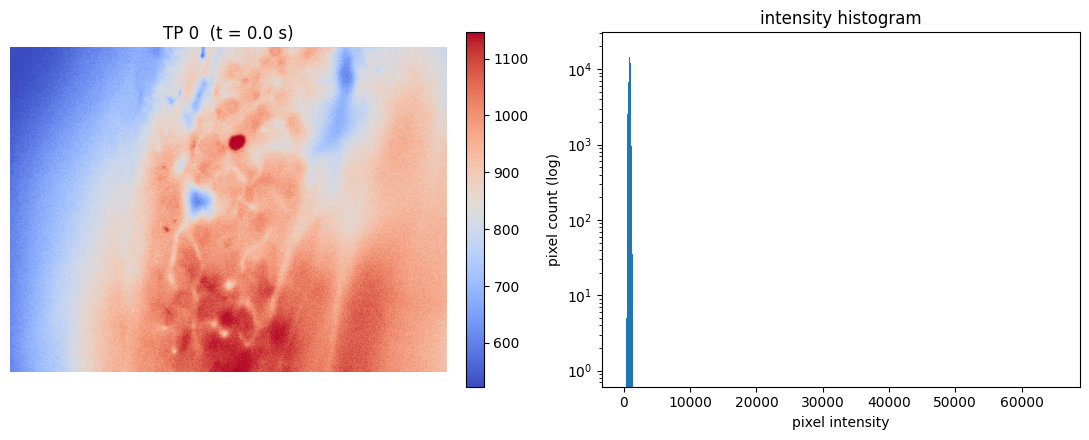

In [17]:
def show_frame_and_histogram(timepoint: int, index: pl.DataFrame = file_index) -> None:
    frame = load_frame(timepoint, index)
    hist = load_histogram(timepoint, index)
    elapsed_s = index.filter(pl.col("timepoint") == timepoint)["elapsed_s"].item()

    vmin, vmax = np.percentile(frame, [1, 99])
    bin_intensity = np.arange(len(hist)) * 4  # verified bin width against HistogramData

    fig, (ax_img, ax_hist) = plt.subplots(1, 2, figsize=(11, 4.5))
    im = ax_img.imshow(frame, cmap="coolwarm", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax_img, fraction=0.046, pad=0.04)
    ax_img.set_title(f"TP {timepoint}  (t = {elapsed_s:.1f} s)")
    ax_img.axis("off")

    ax_hist.bar(bin_intensity, hist, width=4, color="tab:blue")
    ax_hist.set_yscale("log")
    ax_hist.set_xlabel("pixel intensity")
    ax_hist.set_ylabel("pixel count (log)")
    ax_hist.set_title("intensity histogram")
    fig.tight_layout()
    plt.show()


show_frame_and_histogram(0)


## 5. Interactive frame browser

Drag the slider to scrub through the recording. Re-renders the frame +
histogram view above for any timepoint.


In [18]:
widgets.interact(
    show_frame_and_histogram,
    timepoint=widgets.IntSlider(
        value=0, min=0, max=file_index.height - 1, step=1,
        description="timepoint", continuous_update=False, layout=widgets.Layout(width="600px"),
    ),
    index=widgets.fixed(file_index),
);


interactive(children=(IntSlider(value=0, continuous_update=False, description='timepoint', layout=Layout(width…

## 6. Per-frame statistics for the whole recording

Streams through every frame once (only one ~2.8 MB frame in memory at a time)
and computes summary statistics. Takes roughly 15-20 seconds for the full
3220-frame recording. The result is cached to
`analysis_cache/frame_stats_ch<CHANNEL>.parquet`, so subsequent runs load
instantly instead of recomputing.

Set `FORCE_RECOMPUTE = True` to ignore the cache (e.g. after re-exporting the data).


In [19]:
FORCE_RECOMPUTE = False
STATS_CACHE = CACHE_DIR / f"frame_stats_ch{CHANNEL}.parquet"


def compute_frame_stats(index: pl.DataFrame = file_index, cache_path: Path = STATS_CACHE,
                         force_recompute: bool = FORCE_RECOMPUTE) -> pl.DataFrame:
    if cache_path.exists() and not force_recompute:
        return pl.read_parquet(cache_path)

    rows = []
    for timepoint, path in tqdm(
        zip(index["timepoint"], index["image_path"]), total=index.height, desc="scanning frames"
    ):
        frame = np.load(path).squeeze(axis=0)
        p1, p50, p99 = np.percentile(frame, [1, 50, 99])
        rows.append({
            "timepoint": timepoint,
            "mean": float(frame.mean()),
            "std": float(frame.std()),
            "min": int(frame.min()),
            "max": int(frame.max()),
            "p01": p1,
            "p50": p50,
            "p99": p99,
        })

    stats = pl.DataFrame(rows).join(
        index.select("timepoint", "elapsed_s"), on="timepoint", how="left"
    ).sort("timepoint")
    stats.write_parquet(cache_path)
    return stats


frame_stats = compute_frame_stats()
frame_stats.head()


timepoint,mean,std,min,max,p01,p50,p99,elapsed_s
i64,f64,f64,i64,i64,f64,f64,f64,f64
0,873.746668,144.491668,384,1494,523.0,897.0,1146.0,0.0
1,872.509355,144.247367,386,1486,522.0,895.0,1145.0,0.099
2,871.735855,144.013866,398,1496,522.0,895.0,1143.0,0.199
3,871.472585,143.975604,386,1507,522.0,894.0,1143.0,0.299
4,871.626288,143.804658,391,1498,522.0,894.0,1143.0,0.399


## 7. Whole-frame intensity trace

Mean pixel intensity across the whole frame, over time — a coarse, whole-field
proxy for overall activity (shaded band = +/-1 std across pixels). For a real
calcium trace you want an ROI over actual tissue, which the next section covers.


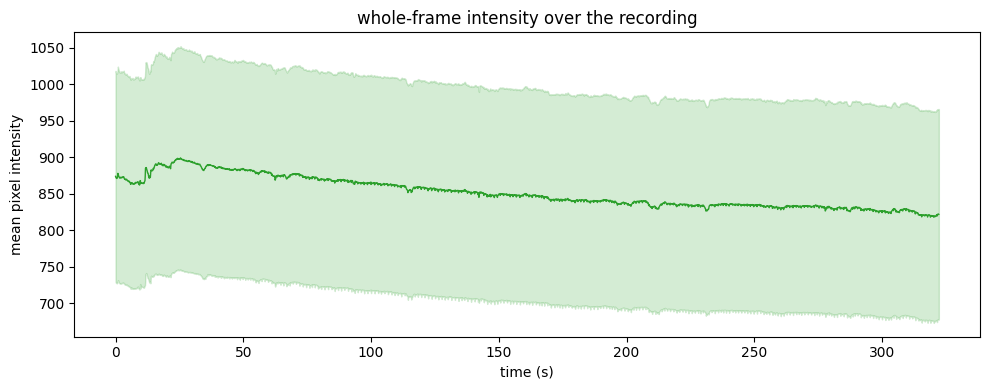

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))
t = frame_stats["elapsed_s"].to_numpy()
mean = frame_stats["mean"].to_numpy()
std = frame_stats["std"].to_numpy()

ax.plot(t, mean, color="tab:green", lw=1)
ax.fill_between(t, mean - std, mean + std, color="tab:green", alpha=0.2)
ax.set_xlabel("time (s)")
ax.set_ylabel("mean pixel intensity")
ax.set_title("whole-frame intensity over the recording")
fig.tight_layout()
plt.show()


## 7.5 Motion correction (rigid + non-rigid) — is the heartbeat moving the field?

This is in-vivo **mouse** data, so the two things that physically move the tissue are
**breathing** (~1–2 Hz here) and the **heartbeat** (~5–12 Hz in a mouse). At a 10 Hz
frame rate the heartbeat sits *at or above* the 5 Hz Nyquist limit, so it can't be
cleanly resolved or temporal-filtered out — but **image registration doesn't care
about frequency**: it aligns each frame to a common template independently, so it
removes whatever displacement a frame happens to carry.

The approach here is **numpy/scipy only** (no CaImAn or scikit-image needed on the
`Cajal` kernel):

1. **Rigid** — sub-pixel translation of every frame onto a template, via FFT **phase
   correlation** (which normalises out brightness, so a cell *getting brighter* isn't
   mistaken for motion). Corrects bulk drift and whole-field breathing sway.
2. **Non-rigid (NoRMCorre-style)** — a grid of overlapping patches, each rigidly
   registered, then a smooth displacement field interpolated across the frame. Catches
   *local* deformation a single global shift can't.

The headline diagnostic is the **frame-to-frame difference energy**
`⟨(Fₜ − Fₜ₋₁)²⟩` before vs after correction: if motion is real, correction pulls it
down; if the difference is just shot noise, correction barely moves it. This runs
**before section 8**, because uncorrected motion inflates the very frame-difference
noise floor section 8 relies on, and shows up there as false ROIs hugging structural
edges.

> **What this recording actually shows** (measured by the cells below): the field is
> remarkably stable — the cached diagnostic keeps the global shift **< 0.22 px** and
> correction drops the frame-to-frame difference by only **~3 %**. So the heartbeat is
> *not* producing meaningful whole-field displacement here; the frame-to-frame
> difference is dominated by **shot noise**, not motion (there is a faint, edge-localised
> sub-pixel residual, but it is small next to the noise floor). The section is kept as a
> **diagnostic** — proof the FOV is stable — and as ready-to-enable infrastructure for a
> shakier prep: flip `MC_MODE` in the last cell to route detection through corrected
> frames.

In [21]:
# ============================================================================
# Motion-correction toolkit  —  numpy + scipy only, no extra dependencies
# ============================================================================
from numpy.fft import fft2, ifft2


def _phase_shift(ref_fft: np.ndarray, img: np.ndarray) -> tuple[float, float]:
    '''Sub-pixel (dy, dx) so that ndimage.shift(img, (dy, dx)) aligns img onto the
    reference whose FFT is `ref_fft`. Phase correlation whitens the spectrum, so it
    keys on structure, not brightness — a cell brightening won't look like motion.'''
    cross = ref_fft * np.conj(fft2(img))
    cross /= np.abs(cross) + 1e-8
    corr = np.real(ifft2(cross))
    py, px = np.unravel_index(np.argmax(corr), corr.shape)
    h, w = corr.shape

    def _refine(m1, z0, p1):                       # 3-point parabolic sub-sample peak
        denom = m1 - 2 * z0 + p1
        return 0.0 if denom == 0 else 0.5 * (m1 - p1) / denom

    z0 = corr[py, px]
    dy = py + _refine(corr[(py - 1) % h, px], z0, corr[(py + 1) % h, px])
    dx = px + _refine(corr[py, (px - 1) % w], z0, corr[py, (px + 1) % w])
    if dy > h / 2:                                  # unwrap the FFT's circular shift
        dy -= h
    if dx > w / 2:
        dx -= w
    return dy, dx


def build_template(index: pl.DataFrame = file_index, n_sample: int = 150,
                   ds: int = 1) -> np.ndarray:
    '''Mean of preprocessed frames spread across the recording — a stable reference.'''
    tps = index["timepoint"].to_numpy()
    pick = tps[np.linspace(0, len(tps) - 1, min(n_sample, len(tps))).astype(int)]
    acc = None
    for tp in pick:
        f = load_processed_frame(int(tp), index)
        acc = f if acc is None else acc + f
    return (acc / len(pick))[::ds, ::ds]


def _patch_shifts(ref: np.ndarray, img: np.ndarray, grid=(4, 6),
                  overlap: float = 0.5, ds: int = 1) -> np.ndarray:
    '''Rigid shift of each overlapping patch -> (gy, gx, 2) array of (dy, dx).'''
    h, w = ref.shape
    gy, gx = grid
    ph, pw = int(round(h / gy * (1 + overlap))), int(round(w / gx * (1 + overlap)))
    cy, cx = (np.arange(gy) + 0.5) * h / gy, (np.arange(gx) + 0.5) * w / gx
    out = np.zeros((gy, gx, 2))
    for i, y in enumerate(cy):
        for j, x in enumerate(cx):
            y0 = int(np.clip(y - ph / 2, 0, h - ph))
            x0 = int(np.clip(x - pw / 2, 0, w - pw))
            rp = ref[y0:y0 + ph, x0:x0 + pw][::ds, ::ds]
            ip = img[y0:y0 + ph, x0:x0 + pw][::ds, ::ds]
            dy, dx = _phase_shift(fft2(rp), ip)
            out[i, j] = (dy * ds, dx * ds)
    return out


def apply_correction(frame: np.ndarray, shift=None, patch_shifts=None) -> np.ndarray:
    '''Warp one frame by a rigid `shift` and/or a non-rigid `patch_shifts` field.'''
    if patch_shifts is not None:
        gy, gx, _ = patch_shifts.shape
        h, w = frame.shape
        fy = ndimage.zoom(patch_shifts[..., 0], (h / gy, w / gx), order=1, mode="nearest")[:h, :w]
        fx = ndimage.zoom(patch_shifts[..., 1], (h / gy, w / gx), order=1, mode="nearest")[:h, :w]
        if shift is not None:
            fy, fx = fy + shift[0], fx + shift[1]
        yy, xx = np.mgrid[0:h, 0:w]
        return ndimage.map_coordinates(frame, [yy - fy, xx - fx], order=1, mode="nearest")
    if shift is not None:
        return ndimage.shift(frame, shift, order=1, mode="nearest")
    return frame

rigid motion:   0%|          | 0/3220 [00:00<?, ?it/s]

rigid shift |px|:  median=0.137  p95=0.609  max=5.362
frames |shift|>0.5px: 259 / 3220   >1px: 35
frame-to-frame diff energy:  raw=48.6  ->  rigid=43.8  (+10%)


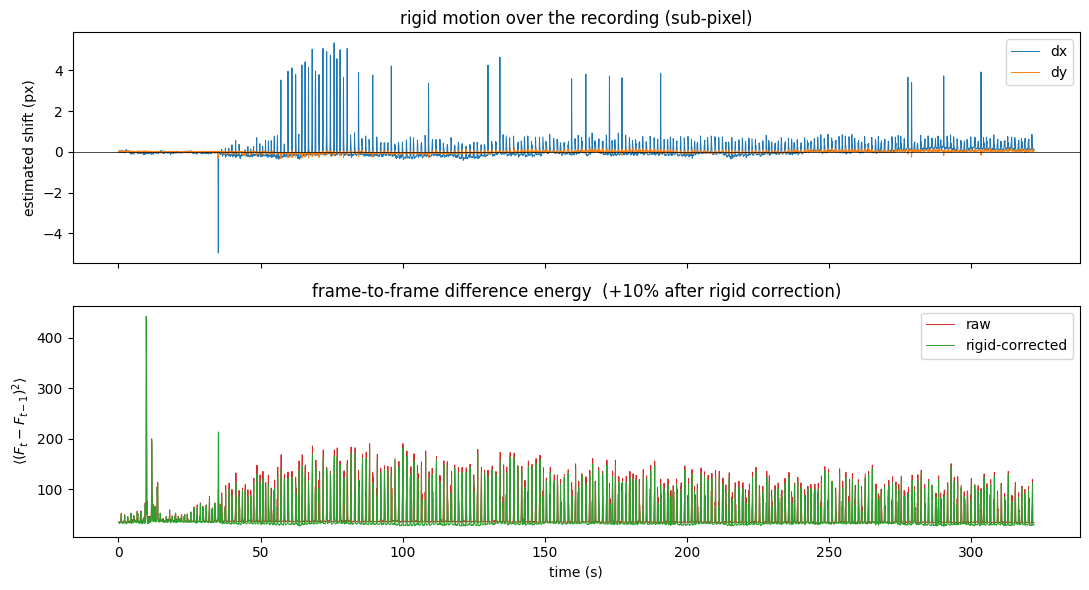

In [22]:
# --- estimate per-frame rigid motion over the whole recording (streaming + cached) ---
MC_DS = 2          # spatial downsample for shift estimation (2 = ~4x faster; sub-px still fine)
MC_GRID = (4, 6)   # non-rigid patch grid (rows, cols); used by the comparison + toolkit

RIGID_CACHE = CACHE_DIR / f"mc_rigid_ch{CHANNEL}_{DENOISE_METHOD}_g{DENOISE_SIGMA}_p{BACKGROUND_PERCENTILE}_ds{MC_DS}.npz"


def estimate_rigid(index: pl.DataFrame = file_index, cache_path=RIGID_CACHE,
                   force_recompute: bool = False) -> dict:
    '''One streaming pass: per-frame rigid shift to a global template, plus the raw and
    rigid-corrected frame-to-frame difference energy. Cached like the rest of the notebook.'''
    if cache_path.exists() and not force_recompute:
        return dict(np.load(cache_path))
    tf = fft2(build_template(index, ds=MC_DS))
    tps = index["timepoint"].to_numpy()
    n = len(tps)
    shifts = np.zeros((n, 2))
    de_raw, de_cor = np.zeros(n), np.zeros(n)
    prev = prev_c = None
    for i, tp in enumerate(tqdm(tps, desc="rigid motion")):
        f = load_processed_frame(int(tp), index)
        dy, dx = _phase_shift(tf, f[::MC_DS, ::MC_DS])
        s = np.array([dy * MC_DS, dx * MC_DS])
        shifts[i] = s
        fc = ndimage.shift(f, s, order=1, mode="nearest")
        if prev is not None:
            de_raw[i] = np.mean((f - prev) ** 2)
            de_cor[i] = np.mean((fc - prev_c) ** 2)
        prev, prev_c = f, fc
    out = {"shifts": shifts, "de_raw": de_raw, "de_cor": de_cor,
           "elapsed_s": index["elapsed_s"].to_numpy()}
    np.savez_compressed(cache_path, **out)
    return out


mc = estimate_rigid()
shifts, de_raw, de_cor, t = mc["shifts"], mc["de_raw"], mc["de_cor"], mc["elapsed_s"]
mag = np.hypot(shifts[:, 0], shifts[:, 1])
reduction = 100 * (1 - de_cor[1:].mean() / de_raw[1:].mean())
print(f"rigid shift |px|:  median={np.median(mag):.3f}  p95={np.percentile(mag, 95):.3f}  max={mag.max():.3f}")
print(f"frames |shift|>0.5px: {(mag > 0.5).sum()} / {len(mag)}   >1px: {(mag > 1).sum()}")
print(f"frame-to-frame diff energy:  raw={de_raw[1:].mean():.1f}  ->  rigid={de_cor[1:].mean():.1f}  ({reduction:+.0f}%)")

fig, (a0, a1) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
a0.plot(t, shifts[:, 1], lw=0.7, color="tab:blue", label="dx")
a0.plot(t, shifts[:, 0], lw=0.7, color="tab:orange", label="dy")
a0.axhline(0, color="k", lw=0.5)
a0.set_ylabel("estimated shift (px)")
a0.set_title("rigid motion over the recording (sub-pixel)")
a0.legend(loc="upper right")
a1.plot(t[1:], de_raw[1:], lw=0.7, color="tab:red", label="raw")
a1.plot(t[1:], de_cor[1:], lw=0.7, color="tab:green", label="rigid-corrected")
a1.set_ylabel(r"$\langle(F_t-F_{t-1})^2\rangle$")
a1.set_xlabel("time (s)")
a1.set_title(f"frame-to-frame difference energy  ({reduction:+.0f}% after rigid correction)")
a1.legend(loc="upper right")
fig.tight_layout()
plt.show()

window compare:   0%|          | 0/400 [00:00<?, ?it/s]

mean frame-to-frame diff energy: {'raw': 50.9, 'rigid': 47.0, 'non-rigid': 49.0}
corr(Var[d], intensity)=0.06   corr(Var[d], edges)=0.66   corr(shot-noise residual, edges)=0.66   (edge-heavy residual = sub-pixel motion)


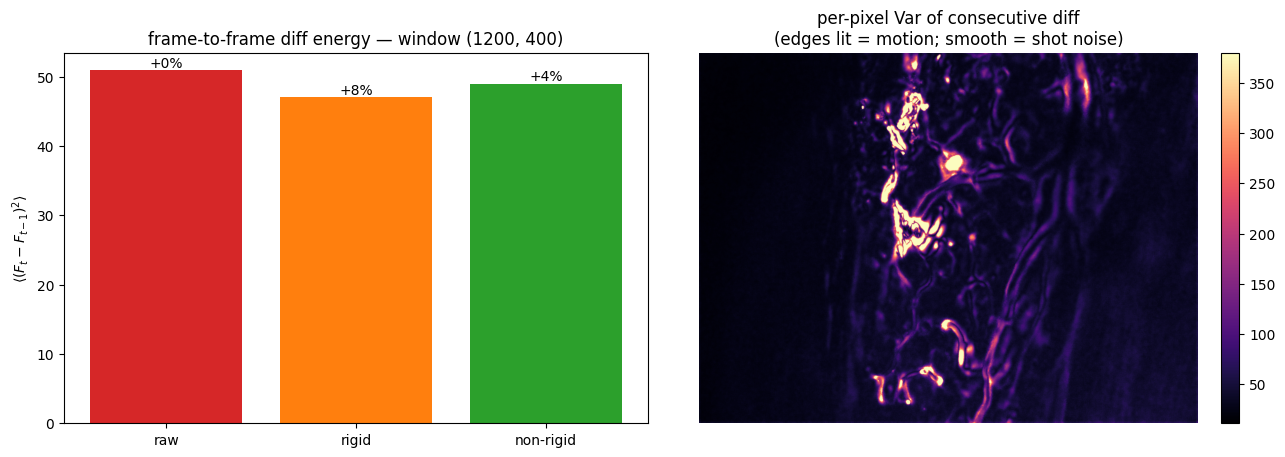

In [23]:
# --- 3-way before/after on a CONSECUTIVE window (raw vs rigid vs non-rigid) ---
# The fast heartbeat effect only shows on adjacent frames (100 ms apart); sampling every
# Nth frame scrambles the cardiac phase, so we compare a consecutive block here.
MC_WINDOW = (1200, 400)          # (start timepoint, number of consecutive frames)


def compare_window(index: pl.DataFrame = file_index, window=MC_WINDOW,
                   grid=MC_GRID, ds: int = MC_DS):
    start, n = window
    tps = index.filter((pl.col("timepoint") >= start) &
                       (pl.col("timepoint") < start + n))["timepoint"].to_numpy()
    frames = np.stack([load_processed_frame(int(tp), index) for tp in tps])
    template = frames.mean(0)
    tf = fft2(template[::ds, ::ds])
    de = {"raw": [], "rigid": [], "non-rigid": []}
    prev = {k: None for k in de}
    for f in tqdm(frames, desc="window compare"):
        dy, dx = _phase_shift(tf, f[::ds, ::ds])
        rc = ndimage.shift(f, (dy * ds, dx * ds), order=1, mode="nearest")
        nc = apply_correction(f, patch_shifts=_patch_shifts(template, f, grid=grid, ds=ds))
        cur = {"raw": f, "rigid": rc, "non-rigid": nc}
        for k in de:
            if prev[k] is not None:
                de[k].append(np.mean((cur[k] - prev[k]) ** 2))
            prev[k] = cur[k]
    return frames, {k: float(np.mean(v)) for k, v in de.items()}


frames_w, de_means = compare_window()

# Where does the frame-to-frame variance live? intensity (= shot noise) vs edges (= motion)
mean_img = frames_w.mean(0)
var_diff = np.diff(frames_w, axis=0).var(0)
edges = ndimage.gaussian_gradient_magnitude(mean_img, 1.0)


def _corr(a, b):
    a, b = a.ravel() - a.mean(), b.ravel() - b.mean()
    return float((a * b).sum() / np.sqrt((a * a).sum() * (b * b).sum()))


A = np.vstack([mean_img.ravel(), np.ones(mean_img.size)]).T
coef = np.linalg.lstsq(A, var_diff.ravel(), rcond=None)[0]
resid = (var_diff.ravel() - A @ coef).reshape(var_diff.shape)   # variance not explained by intensity
print("mean frame-to-frame diff energy:", {k: round(v, 1) for k, v in de_means.items()})
print(f"corr(Var[d], intensity)={_corr(var_diff, mean_img):.2f}   "
      f"corr(Var[d], edges)={_corr(var_diff, edges):.2f}   "
      f"corr(shot-noise residual, edges)={_corr(resid, edges):.2f}   (edge-heavy residual = sub-pixel motion)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
base = de_means["raw"]
ax[0].bar(de_means.keys(), de_means.values(), color=["tab:red", "tab:orange", "tab:green"])
for i, v in enumerate(de_means.values()):
    ax[0].text(i, v, f"{100 * (1 - v / base):+.0f}%", ha="center", va="bottom")
ax[0].set_ylabel(r"$\langle(F_t-F_{t-1})^2\rangle$")
ax[0].set_title(f"frame-to-frame diff energy — window {MC_WINDOW}")
im = ax[1].imshow(var_diff, cmap="magma", vmax=np.percentile(var_diff, 99))
ax[1].set_title("per-pixel Var of consecutive diff\n(edges lit = motion; smooth = shot noise)")
ax[1].axis("off")
fig.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

In [54]:
# --- optionally route ROI detection (section 8) through motion-corrected frames ---
MC_MODE = "rigid"    # "none" | "rigid"   (flip to "rigid" to apply the stored correction)

_mc = estimate_rigid()                                                   # cached rigid shifts
_mc_row = {int(tp): i for i, tp in enumerate(file_index["timepoint"].to_numpy())}


def load_registered_frame(timepoint: int, index: pl.DataFrame = file_index) -> np.ndarray:
    '''load_processed_frame + the stored rigid correction when MC_MODE == "rigid".'''
    f = load_processed_frame(timepoint, index)
    if MC_MODE == "rigid":
        f = ndimage.shift(f, _mc["shifts"][_mc_row[int(timepoint)]], order=1, mode="nearest")
    return f


# Section 8's compute_activity_map streams by file path for speed. To make it use the
# correction, replace its per-frame load line
#     y = preprocess_frame(np.load(path).squeeze(axis=0)).astype(np.float64).ravel()
# with
#     y = load_registered_frame(int(index["timepoint"][i])).astype(np.float64).ravel()
# For THIS recording it changes almost nothing (shift < 0.22 px, ~3% diff energy), so it
# is left OFF by default; enable it if you re-image a less-stable prep.
print(f'MC_MODE = "{MC_MODE}"  ->  load_registered_frame() '
      f'{"APPLIES" if MC_MODE != "none" else "does NOT apply"} rigid correction')

MC_MODE = "rigid"  ->  load_registered_frame() APPLIES rigid correction


## 8. Choose the ROIs: supplied TIFF labels (default) or automatic detection

Use the selector below to choose the ROI source used by every downstream section:

- **Provided TIFF mask (default)** loads `_labels/Debi_DRG_ROI.tiff`. It is a
  `(1024, 1376)` integer label image matching the movie exactly: `0` is background
  and labels `1..40` are the 40 ROIs. Each label is kept as its own mask.
- **Automatic detection** uses the numerical structured-SNR criterion described
  below. Its expensive activity map is computed lazily only when this option is
  selected, so the default TIFF workflow does not require another full movie pass.

After changing the selector or automatic-detection settings, re-run section 9 and
the sections below it so the extracted traces match the active ROI set.

### Automatic criterion

For each pixel, the automatic route removes a cubic photobleaching trend, estimates
white-noise variance from consecutive-frame differences, and measures the remaining
slow structured variance relative to that noise floor. A broad field-wide component
is removed, the localized excess is robustly thresholded, and small connected
components are discarded. This statistic can still contain motion artifacts, so
automatic ROIs require visual inspection.


In [55]:
ACTIVITY_CACHE = CACHE_DIR / f"activity_map_ch{CHANNEL}_{DENOISE_METHOD}_g{DENOISE_SIGMA}_p{BACKGROUND_PERCENTILE}.npz"


def compute_activity_map(index: pl.DataFrame = file_index, cache_path: Path = ACTIVITY_CACHE,
                         force_recompute: bool = False, poly_degree: int = 3) -> dict:
    '''Per-pixel structured-signal-to-shot-noise map, in one streaming pass.

    Runs on preprocessed (denoised + background-subtracted) frames. Accumulates
    only Xᵀy, Σy² and Σ(Δy)², so memory stays at a handful of full-frame arrays.
    '''
    if cache_path.exists() and not force_recompute:
        return dict(np.load(cache_path))

    paths = index["image_path"].to_list()
    tps = index["timepoint"].to_list()
    n_t = len(paths)
    t_basis = np.linspace(-1, 1, n_t)
    design = np.vander(t_basis, poly_degree + 1)
    gram = design.T @ design

    h, w = load_processed_frame(int(index["timepoint"][0]), index).shape
    xty = np.zeros((poly_degree + 1, h * w))
    sum_sq = np.zeros(h * w)
    sum_diff_sq = np.zeros(h * w)
    previous = None

    for i, path in enumerate(tqdm(paths, desc="activity map")):
        y = load_preprocessed(int(tps[i]), index, path=path).astype(np.float64).ravel()
        xty += np.outer(design[i], y)
        sum_sq += y * y
        if previous is not None:
            delta = y - previous
            sum_diff_sq += delta * delta
        previous = y

    coef = np.linalg.solve(gram, xty)
    rss = np.maximum(sum_sq - np.einsum("ij,ij->j", coef, xty), 0)
    residual_var = rss / (n_t - (poly_degree + 1))
    noise_var = sum_diff_sq / (2 * (n_t - 1))
    structured = np.maximum(residual_var - noise_var, 0)
    snr = np.divide(
        np.sqrt(structured), np.sqrt(noise_var),
        out=np.zeros_like(structured), where=noise_var > 0,
    )

    result = {
        "snr": snr.reshape(h, w),
        "noise_var": noise_var.reshape(h, w),
        "residual_var": residual_var.reshape(h, w),
        "mean": coef[-1].reshape(h, w),
    }
    np.savez_compressed(cache_path, **result)
    return result


def detect_rois(snr: np.ndarray, z_threshold: float = 6.0, min_area_px: int = 200,
                smooth_sigma: float = 2.0, background_sigma: float = 40.0) -> list[np.ndarray]:
    '''Threshold the localized SNR excess and return one boolean mask per region.'''
    local_excess = (
        ndimage.gaussian_filter(snr, smooth_sigma)
        - ndimage.gaussian_filter(snr, background_sigma)
    )
    median = np.median(local_excess)
    robust_sigma = 1.4826 * np.median(np.abs(local_excess - median))
    binary = local_excess > median + z_threshold * robust_sigma
    binary = ndimage.binary_opening(binary, np.ones((3, 3)))
    binary = ndimage.binary_fill_holes(binary)

    labels, n_labels = ndimage.label(binary)
    if n_labels == 0:
        return []
    areas = ndimage.sum(binary, labels, range(1, n_labels + 1))
    kept = [i + 1 for i, area in enumerate(areas) if area >= min_area_px]
    kept.sort(key=lambda i: -areas[i - 1])
    return [labels == i for i in kept]


def load_label_masks(path: Path, expected_shape: tuple[int, int]) -> tuple[np.ndarray, np.ndarray, list[np.ndarray]]:
    '''Load a semantic TIFF label map: 0=background and each positive integer=one ROI.'''
    if not path.is_file():
        raise FileNotFoundError(f"ROI label image not found: {path}")
    label_map = np.squeeze(tifffile.imread(path))
    if label_map.shape != expected_shape:
        raise ValueError(f"ROI label map shape {label_map.shape} != frame shape {expected_shape}")
    if not np.issubdtype(label_map.dtype, np.integer):
        integer_valued = np.isfinite(label_map).all() and np.equal(label_map, np.rint(label_map)).all()
        if not integer_valued:
            raise ValueError("ROI label image must contain finite integer labels")
        label_map = np.rint(label_map).astype(np.int32)
    label_ids = np.unique(label_map)
    label_ids = label_ids[label_ids > 0]
    if label_ids.size == 0:
        raise ValueError(f"ROI label image contains no positive labels: {path}")
    return label_map, label_ids, [label_map == label_id for label_id in label_ids]


def draw_roi_masks(masks: list[np.ndarray], background: np.ndarray, title: str = "") -> None:
    vmin, vmax = np.percentile(background, [2, 98])
    fig, ax = plt.subplots(figsize=(11, 8))
    ax.imshow(background, cmap="gray", vmin=vmin, vmax=vmax)
    colors = plt.cm.tab20.colors
    overlay = np.zeros((*background.shape, 4))
    for i, mask in enumerate(masks):
        color = colors[i % len(colors)]
        overlay[mask] = (*color, 0.55)
        ax.contour(mask, levels=[0.5], colors=[color], linewidths=1.0)
        ys, xs = np.nonzero(mask)
        ax.text(xs.mean(), ys.mean(), str(i + 1), color="yellow", fontsize=8,
                ha="center", va="center", weight="bold")
    ax.imshow(overlay)
    ax.set_title(title or f"{len(masks)} ROIs")
    ax.axis("off")
    fig.tight_layout()
    plt.show()


Z_THRESHOLD = 6.0
MIN_AREA_PX = 200

first_tp = int(file_index["timepoint"][0])
roi_reference_frame = load_processed_frame(first_tp, file_index)
tiff_label_map, TIFF_LABEL_IDS, TIFF_ROI_MASKS = load_label_masks(
    ROI_LABEL_PATH, roi_reference_frame.shape
)

# Automatic state is lazy: selecting TIFF does not compute the full activity map.
activity = None
AUTO_ROI_MASKS = None


def _ensure_auto_rois() -> list[np.ndarray]:
    global activity, AUTO_ROI_MASKS
    if activity is None:
        activity = compute_activity_map()
    if AUTO_ROI_MASKS is None:
        AUTO_ROI_MASKS = detect_rois(
            activity["snr"], z_threshold=Z_THRESHOLD, min_area_px=MIN_AREA_PX
        )
    return AUTO_ROI_MASKS


def activate_roi_source(source: str) -> None:
    '''Make one ROI source active for section 9 and every downstream analysis.'''
    global ROI_SOURCE, roi_masks, ROI_NAMES
    if source == "tiff":
        roi_masks = TIFF_ROI_MASKS
        ROI_NAMES = [f"roi_{int(label_id):02d}" for label_id in TIFF_LABEL_IDS]
        background = roi_reference_frame
        title = f"Provided TIFF mask: {len(roi_masks)} labeled ROIs"
    elif source == "auto":
        roi_masks = _ensure_auto_rois()
        ROI_NAMES = [f"roi_{i + 1:02d}" for i in range(len(roi_masks))]
        background = activity["mean"]
        title = (
            f"Automatic detection: {len(roi_masks)} ROIs "
            f"(z>{Z_THRESHOLD}, area>={MIN_AREA_PX}px)"
        )
    else:
        raise ValueError(f"unknown ROI source: {source!r}")

    ROI_SOURCE = source
    print(f"active ROI source: {ROI_SOURCE}; {len(roi_masks)} ROIs")
    print(f"areas (px): {[int(mask.sum()) for mask in roi_masks]}")
    print("After changing this selection, re-run section 9 onward.")
    draw_roi_masks(roi_masks, background, title=title)


roi_source_selector = widgets.ToggleButtons(
    options=[
        (f"Provided TIFF mask ({len(TIFF_ROI_MASKS)}) — default", "tiff"),
        ("Automatic detection", "auto"),
    ],
    value=ROI_SOURCE_DEFAULT,
    description="ROI source:",
    style={"description_width": "initial"},
)
widgets.interact(activate_roi_source, source=roi_source_selector);


interactive(children=(ToggleButtons(description='ROI source:', options=(('Provided TIFF mask (40) — default', …

In [56]:
# These controls affect only the automatic option. Lower z / smaller area => more ROIs.
def _tune_detection(z_threshold: float, min_area_px: int) -> None:
    global Z_THRESHOLD, MIN_AREA_PX, AUTO_ROI_MASKS
    Z_THRESHOLD, MIN_AREA_PX = z_threshold, min_area_px
    if ROI_SOURCE != "auto":
        AUTO_ROI_MASKS = None
        print("Automatic settings saved. Switch ROI source to 'Automatic detection' to compute/preview them.")
        return

    if activity is None:
        _ensure_auto_rois()
    AUTO_ROI_MASKS = detect_rois(
        activity["snr"], z_threshold=z_threshold, min_area_px=min_area_px
    )
    activate_roi_source("auto")


widgets.interact(
    _tune_detection,
    z_threshold=widgets.FloatSlider(
        value=Z_THRESHOLD, min=2, max=15, step=0.5,
        description="z thresh", continuous_update=False,
    ),
    min_area_px=widgets.IntSlider(
        value=MIN_AREA_PX, min=20, max=2000, step=20,
        description="min area", continuous_update=False,
    ),
);


interactive(children=(FloatSlider(value=6.0, continuous_update=False, description='z thresh', max=15.0, min=2.…

## 9. Turn the selected ROIs into denoised calcium traces

`extract_mask_traces` loads every spatially denoised, background-subtracted frame
once and averages the pixels inside each active mask. The same code therefore works
for all 40 TIFF labels or for any number of automatically detected masks.

A rolling low-percentile baseline converts each fluorescence trace to fractional
dF/F. These are the denoised traces passed to CASCADE in section 9.5; no additional
temporal smoothing or normalization is applied before inference.


40 tiff traces x 3220 timepoints


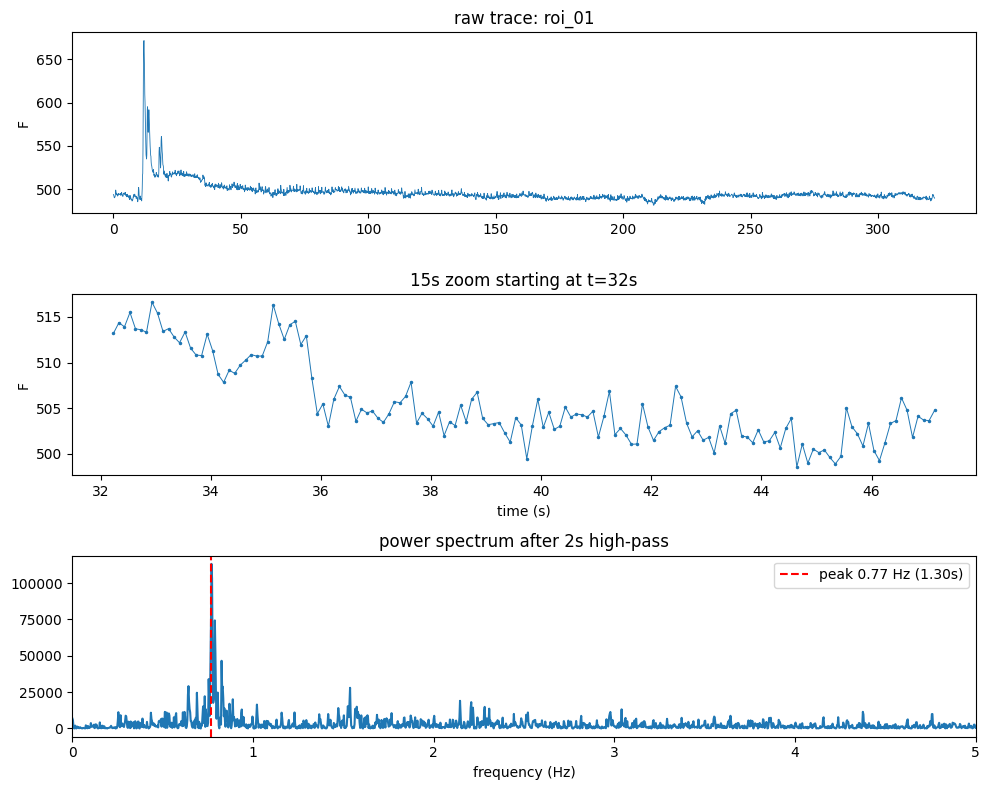

sampling rate: 10.00 Hz
dominant fast oscillation: 0.77 Hz (period 1.30 s) -- likely a physiological artifact (e.g. respiration), not real signal; keep the dF/F baseline window below longer than this period.
residual std after 2s high-pass: 4.88 (raw std: 12.13)


In [57]:
def masks_cache_path(masks: list[np.ndarray]) -> Path:
    '''Cache key follows the mask pixels + preprocessing, so any change misses stale caches.'''
    payload = np.packbits(np.stack(masks)).tobytes() + f"g{DENOISE_SIGMA}p{BACKGROUND_PERCENTILE}m{DENOISE_METHOD}".encode()
    digest = hashlib.md5(payload).hexdigest()[:10]
    return CACHE_DIR / f"roi_traces_ch{CHANNEL}_{ROI_SOURCE}_n{len(masks)}_{digest}.parquet"


def extract_mask_traces(masks: list[np.ndarray], names: list[str],
                         index: pl.DataFrame = file_index,
                         cache_path: Path | None = None) -> pl.DataFrame:
    '''One pass over every preprocessed frame, averaging the pixels inside each mask.'''
    if cache_path is not None and cache_path.exists():
        return pl.read_parquet(cache_path)

    values = np.empty((index.height, len(masks)))
    pixel_indices = [np.flatnonzero(mask) for mask in masks]
    paths = index["image_path"].to_list()
    tps = index["timepoint"].to_list()
    for i, path in enumerate(tqdm(paths, total=index.height,
                                   desc=f"extracting {len(masks)} ROI(s)")):
        frame_flat = load_preprocessed(int(tps[i]), index, path=path).ravel()
        for j, pixels in enumerate(pixel_indices):
            values[i, j] = frame_flat[pixels].mean()

    trace = index.select("timepoint", "elapsed_s").with_columns(
        [pl.Series(name, values[:, j]) for j, name in enumerate(names)]
    )
    if cache_path is not None:
        trace.write_parquet(cache_path)
    return trace


def characterize_drift_and_noise(trace: pl.DataFrame, column: str,
                                  highpass_window_s: float = 2.0) -> None:
    '''High-pass one trace to expose fast oscillations hiding under the slow drift.'''
    t = trace["elapsed_s"].to_numpy()
    f = trace[column].to_numpy()
    fs = 1 / np.median(np.diff(t))
    hp_window = max(3, round(highpass_window_s * fs))

    # median (not a low percentile): we want "typical local value", so wiggles
    # above and below it both land in the residual.
    baseline = trace[column].rolling_quantile(
        quantile=0.5, window_size=hp_window, center=True, min_samples=1
    ).to_numpy()
    residual = f - baseline

    n = len(residual)
    freqs = np.fft.rfftfreq(n, d=1 / fs)
    power = np.abs(np.fft.rfft(residual * np.hanning(n))) ** 2
    valid = freqs > 1 / highpass_window_s     # below this the high-pass itself dominates
    peak_freq = freqs[valid][np.argmax(power[valid])] if valid.any() else np.nan

    zoom_start = 0.1 * t[-1]
    zoom = (t >= zoom_start) & (t <= zoom_start + 15)

    fig, axes = plt.subplots(3, 1, figsize=(10, 8))
    axes[0].plot(t, f, lw=0.6)
    axes[0].set_ylabel("F")
    axes[0].set_title(f"raw trace: {column}")

    axes[1].plot(t[zoom], f[zoom], marker=".", ms=3, lw=0.7)
    axes[1].set_ylabel("F")
    axes[1].set_xlabel("time (s)")
    axes[1].set_title(f"15s zoom starting at t={zoom_start:.0f}s")

    axes[2].plot(freqs, power)
    if not np.isnan(peak_freq):
        axes[2].axvline(peak_freq, color="red", ls="--",
                         label=f"peak {peak_freq:.2f} Hz ({1 / peak_freq:.2f}s)")
        axes[2].legend()
    axes[2].set_xlim(0, min(5, fs / 2))
    axes[2].set_xlabel("frequency (Hz)")
    axes[2].set_title(f"power spectrum after {highpass_window_s:.0f}s high-pass")
    fig.tight_layout()
    plt.show()

    print(f"sampling rate: {fs:.2f} Hz")
    if not np.isnan(peak_freq):
        print(f"dominant fast oscillation: {peak_freq:.2f} Hz (period {1 / peak_freq:.2f} s) "
              "-- likely a physiological artifact (e.g. respiration), not real signal; "
              "keep the dF/F baseline window below longer than this period.")
    print(f"residual std after {highpass_window_s:.0f}s high-pass: {residual.std():.2f} "
          f"(raw std: {f.std():.2f})")


if not roi_masks:
    raise RuntimeError("The active ROI source produced no masks; adjust section 8 first.")

roi_traces = extract_mask_traces(roi_masks, ROI_NAMES, cache_path=masks_cache_path(roi_masks))
print(f"{len(ROI_NAMES)} {ROI_SOURCE} traces x {roi_traces.height} timepoints")
characterize_drift_and_noise(roi_traces, column=ROI_NAMES[0])


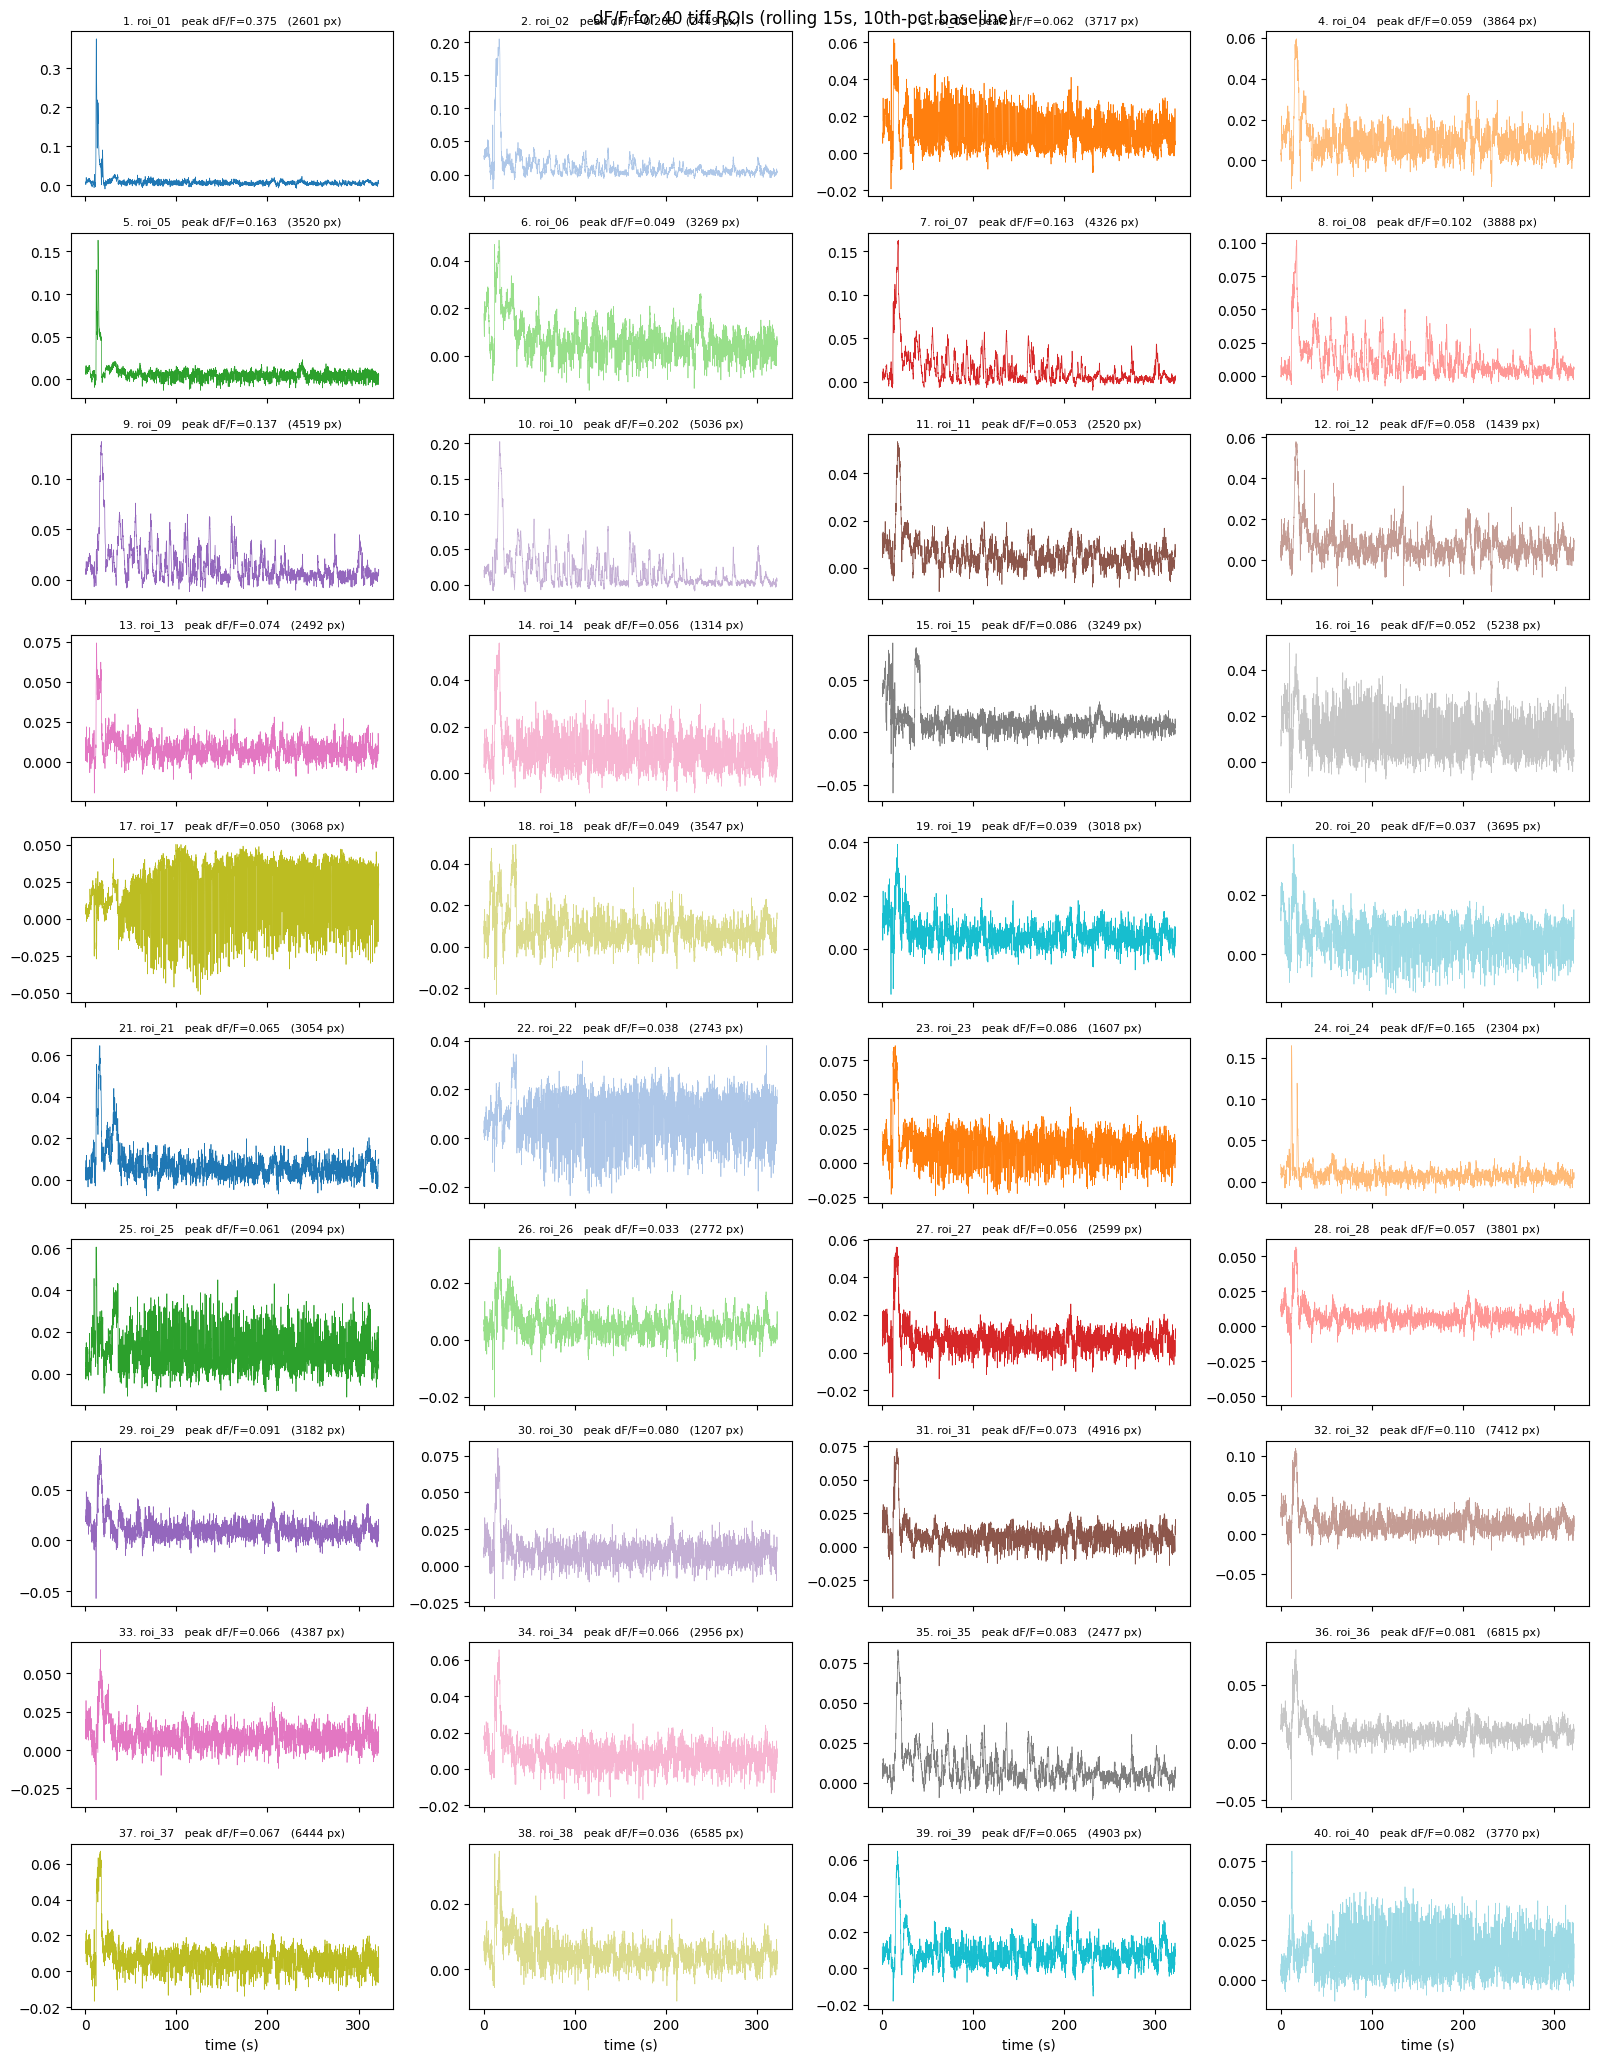

In [58]:
# Baseline window: longer than the fast oscillation found above (so it doesn't chase
# every cycle of it) but short enough to still track the slow drift.
BASELINE_WINDOW_S = 15

fs = 1 / np.median(np.diff(roi_traces["elapsed_s"].to_numpy()))
window_size = max(3, round(BASELINE_WINDOW_S * fs))

for name in ROI_NAMES:
    roi_traces = roi_traces.with_columns(
        pl.col(name)
          .rolling_quantile(quantile=0.10, window_size=window_size, center=True, min_samples=1)
          .alias(f"baseline_{name}")
    ).with_columns(
        ((pl.col(name) - pl.col(f"baseline_{name}")) / pl.col(f"baseline_{name}")).alias(f"dff_{name}")
    )

roi_traces.write_parquet(masks_cache_path(roi_masks))   # persist enriched columns

t = roi_traces["elapsed_s"].to_numpy()
n_cols = 4
n_rows = int(np.ceil(len(ROI_NAMES) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2.1 * n_rows), sharex=True)
colors = plt.cm.tab20.colors
for i, (ax, name) in enumerate(zip(axes.ravel(), ROI_NAMES)):
    dff = roi_traces[f"dff_{name}"].to_numpy()
    ax.plot(t, dff, lw=0.5, color=colors[i % len(colors)])
    ax.set_title(f"{i + 1}. {name}   peak dF/F={dff.max():.3f}   ({int(roi_masks[i].sum())} px)",
                 fontsize=8)
for ax in axes.ravel()[len(ROI_NAMES):]:
    ax.axis("off")
for ax in axes[-1]:
    ax.set_xlabel("time (s)")
fig.suptitle(f"dF/F for {len(ROI_NAMES)} {ROI_SOURCE} ROIs "
             f"(rolling {BASELINE_WINDOW_S:.0f}s, 10th-pct baseline)")
fig.tight_layout()
plt.show()


## 9.5 Infer spikes with the DS40-pretrained CASCADE model

The active ROIs' denoised fractional dF/F traces are sent to the official
`Spinal_cord_excitatory_30Hz_smoothing50ms` model, trained only on
`DS40-GCaMP6s-spinal-cord-excitatory`. TensorFlow runs in the dedicated `CASCADE`
conda environment through `run_cascade_ds40.py`; the notebook itself remains on the
`Cajal` kernel required by image preprocessing.

Important sampling-rate caveat: this movie is 10 Hz, but no official DS40 10 Hz
checkpoint exists. The bridge linearly samples dF/F onto the model's 30 Hz grid,
selects its noise-specific ensemble using noise measured on the original 10 Hz trace,
and then **sums** 30 Hz expected-spike bins into the original timestamp bins. This is
an explicit approximation—interpolation cannot create missing 30 Hz information.
For quantitatively validated 10 Hz inference, train/request a DS40 10 Hz model (or
compare against a frame-rate-matched global 10 Hz CASCADE model).


loading cached CASCADE prediction: cascade_ds40_tiff_88178d98c5a2.npz
native rate: 10.000 Hz; DS40 model rate: 30 Hz
selected model noise levels (level: ROI count): {2: 40}


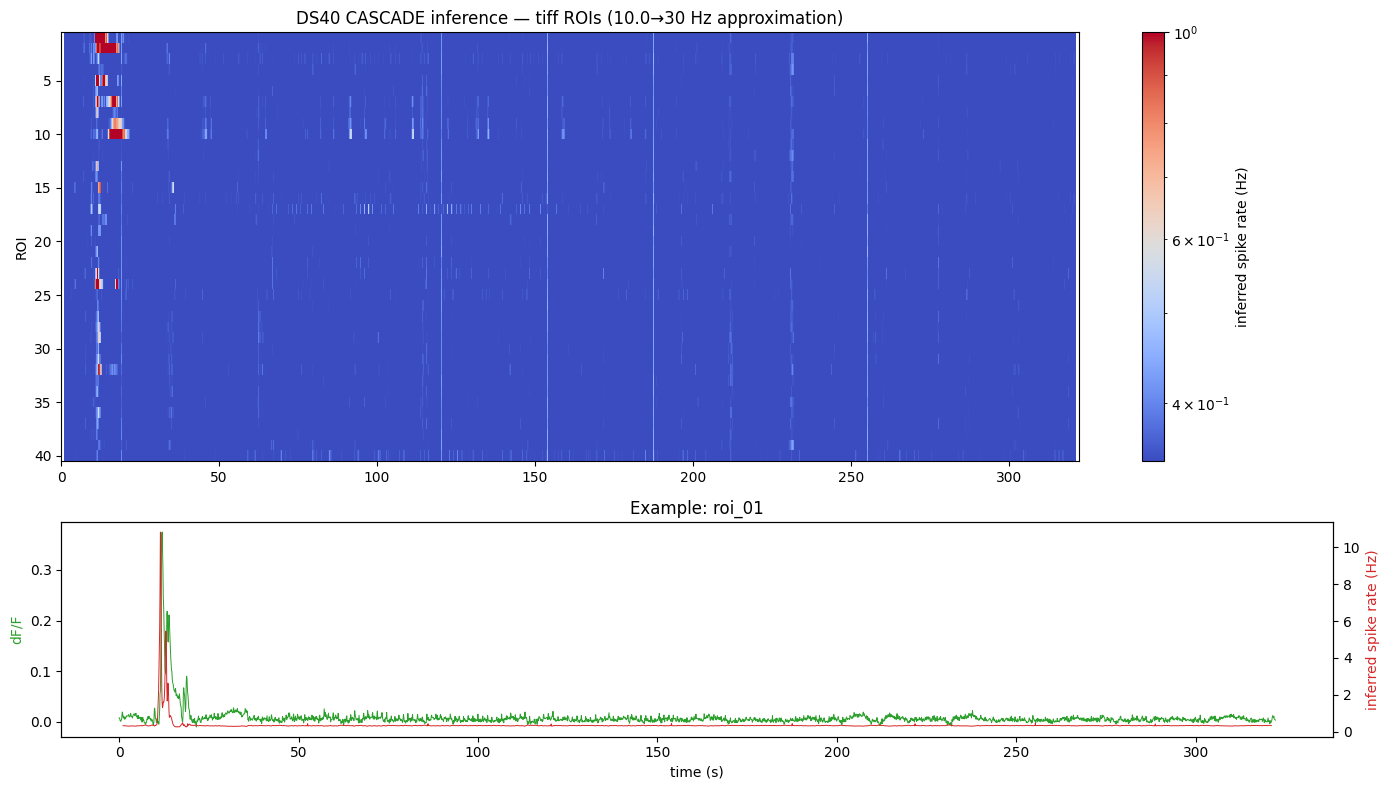

CASCADE cache: /Users/samsonho/KSL/leftDRGcut/analysis_cache/cascade_ds40_tiff_88178d98c5a2.npz


In [59]:
import os
import subprocess
from matplotlib.colors import LogNorm

CASCADE_ENV_PYTHON = Path("/Users/samsonho/exit()/envs/CASCADE/bin/python")
CASCADE_ROOT = Path("/Users/samsonho/KSL/leftDRGcut/cascade_runtime")
CASCADE_MODEL_NAME = "Spinal_cord_excitatory_30Hz_smoothing50ms"
CASCADE_BRIDGE = Path("/Users/samsonho/KSL/leftDRGcut/run_cascade_ds40.py")

t_native = roi_traces["elapsed_s"].to_numpy().astype(np.float64)
cascade_dff = np.vstack([
    roi_traces[f"dff_{name}"].to_numpy() for name in ROI_NAMES
]).astype(np.float32)

if cascade_dff.shape != (len(ROI_NAMES), len(t_native)):
    raise ValueError(f"unexpected CASCADE input shape: {cascade_dff.shape}")
if not np.isfinite(cascade_dff).all():
    raise ValueError("dF/F contains NaN/inf; inspect the rolling baselines before CASCADE")

cache_payload = (
    np.ascontiguousarray(cascade_dff).tobytes()
    + np.ascontiguousarray(t_native).tobytes()
    + CASCADE_MODEL_NAME.encode()
)
cascade_digest = hashlib.md5(cache_payload).hexdigest()[:12]
cascade_input_path = CACHE_DIR / f"cascade_input_{ROI_SOURCE}_{cascade_digest}.npz"
cascade_output_path = CACHE_DIR / f"cascade_ds40_{ROI_SOURCE}_{cascade_digest}.npz"

if not cascade_output_path.exists():
    if not CASCADE_ENV_PYTHON.is_file():
        raise FileNotFoundError(f"CASCADE environment Python not found: {CASCADE_ENV_PYTHON}")
    np.savez_compressed(cascade_input_path, traces=cascade_dff, time_s=t_native)
    mpl_cache = CACHE_DIR / "matplotlib_config_cascade"
    mpl_cache.mkdir(exist_ok=True)
    cascade_env = os.environ.copy()
    cascade_env.update({
        "MPLCONFIGDIR": str(mpl_cache),
        "TF_CPP_MIN_LOG_LEVEL": "2",
        "KMP_DUPLICATE_LIB_OK": "TRUE",
        "PYTHONUNBUFFERED": "1",
    })
    result = subprocess.run(
        [
            str(CASCADE_ENV_PYTHON), str(CASCADE_BRIDGE),
            "--input", str(cascade_input_path),
            "--output", str(cascade_output_path),
            "--cascade-root", str(CASCADE_ROOT),
            "--model", CASCADE_MODEL_NAME,
        ],
        env=cascade_env,
        text=True,
        capture_output=True,
    )
    if result.stdout:
        print(result.stdout.strip())
    if result.returncode != 0:
        if result.stderr:
            print(result.stderr)
        raise RuntimeError(f"CASCADE subprocess failed with exit code {result.returncode}")
else:
    print(f"loading cached CASCADE prediction: {cascade_output_path.name}")

with np.load(cascade_output_path, allow_pickle=False) as cascade_data:
    cascade_model_rate_hz = float(cascade_data["model_rate_hz"])
    cascade_native_rate_hz = float(cascade_data["native_rate_hz"])
    cascade_spikes_native = cascade_data["spikes_per_native_bin"].copy()
    cascade_rates_native = cascade_data["spike_rate_native_hz"].copy()
    cascade_noise_levels = cascade_data["trace_noise_levels"].copy()
    cascade_selected_noise = cascade_data["selected_noise_levels"].copy()
    cascade_available_noise = cascade_data["available_noise_levels"].copy()

if np.any((cascade_noise_levels < cascade_available_noise.min()) |
          (cascade_noise_levels > cascade_available_noise.max())):
    print(
        "WARNING: at least one trace lies outside the model's trained noise range; "
        "CASCADE used the nearest available noise ensemble."
    )

noise_summary = {
    int(level): int(np.sum(cascade_selected_noise == level))
    for level in np.unique(cascade_selected_noise)
}
print(f"native rate: {cascade_native_rate_hz:.3f} Hz; DS40 model rate: {cascade_model_rate_hz:g} Hz")
print(f"selected model noise levels (level: ROI count): {noise_summary}")

cascade_columns = []
for i, name in enumerate(ROI_NAMES):
    cascade_columns.extend([
        pl.Series(f"cascade_spikes_{name}", cascade_spikes_native[i]),
        pl.Series(f"cascade_rate_hz_{name}", cascade_rates_native[i]),
    ])
roi_traces = roi_traces.with_columns(cascade_columns)
roi_traces.write_parquet(masks_cache_path(roi_masks))

finite_rates = cascade_rates_native[np.isfinite(cascade_rates_native)]
heat_vmax = np.percentile(finite_rates, 99) if finite_rates.size else 1.0
fig, (ax_heat, ax_example) = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1])
im = ax_heat.imshow(
    np.ma.masked_invalid(cascade_rates_native),
    aspect="auto", interpolation="nearest", cmap="coolwarm", norm=LogNorm(vmin=1, vmax=heat_vmax),
    extent=[t_native[0], t_native[-1], len(ROI_NAMES) + 0.5, 0.5],
)
fig.colorbar(im, ax=ax_heat, label="inferred spike rate (Hz)")
ax_heat.set_ylabel("ROI")
ax_heat.set_title(
    f"DS40 CASCADE inference — {ROI_SOURCE} ROIs "
    f"({cascade_native_rate_hz:.1f}→{cascade_model_rate_hz:g} Hz approximation)"
)

example_name = ROI_NAMES[0]
ax_example.plot(t_native, roi_traces[f"dff_{example_name}"].to_numpy(),
                color="tab:green", lw=0.7, label="denoised dF/F")
ax_example.set_xlabel("time (s)")
ax_example.set_ylabel("dF/F", color="tab:green")
ax_rate = ax_example.twinx()
ax_rate.plot(t_native, cascade_rates_native[0], color="tab:red", lw=0.7,
             label="CASCADE rate")
ax_rate.set_ylabel("inferred spike rate (Hz)", color="tab:red")
ax_example.set_title(f"Example: {example_name}")
fig.tight_layout()
plt.show()

print(f"CASCADE cache: {cascade_output_path}")


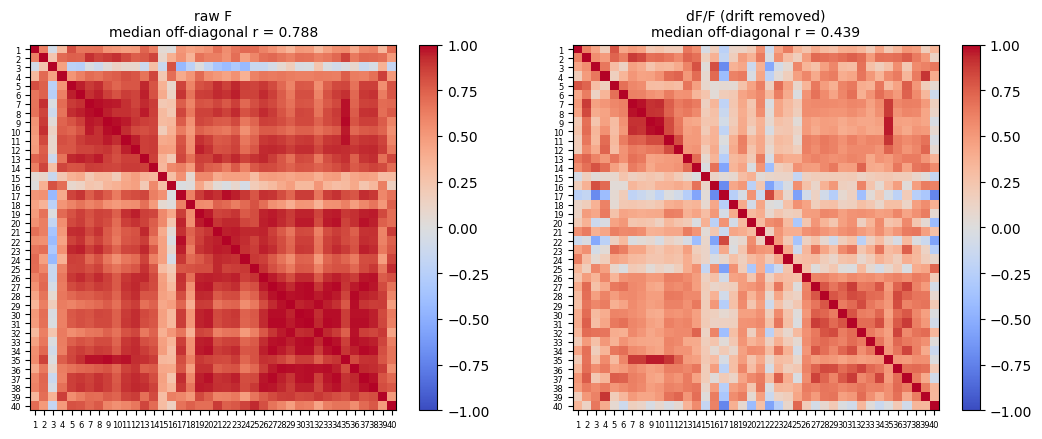

raw   traces: median r=0.788, max r=0.990
dF/F  traces: median r=0.439, max r=0.978

A median r near 1 in both panels would mean every region is really the same field-wide signal (motion/illumination). A large drop from the left panel to the right means the shared component was mostly the slow drift, and the regions carry substantially independent signal. Pairs still near r=1 on the right are worth inspecting -- they may be one source split into two components.


In [60]:
# Are these separate sources, or one field-wide artifact seen n times?
raw_matrix = np.column_stack([roi_traces[n].to_numpy() for n in ROI_NAMES])
dff_matrix = np.column_stack([roi_traces[f"dff_{n}"].to_numpy() for n in ROI_NAMES])

corr_raw = np.corrcoef(raw_matrix.T)
corr_dff = np.corrcoef(dff_matrix.T)
upper = np.triu_indices(len(ROI_NAMES), 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, matrix, label in [(axes[0], corr_raw, "raw F"), (axes[1], corr_dff, "dF/F (drift removed)")]:
    im = ax.imshow(matrix, cmap="coolwarm", vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f"{label}\nmedian off-diagonal r = {np.median(matrix[upper]):.3f}", fontsize=10)
    ax.set_xticks(range(len(ROI_NAMES)))
    ax.set_xticklabels(range(1, len(ROI_NAMES) + 1), fontsize=6)
    ax.set_yticks(range(len(ROI_NAMES)))
    ax.set_yticklabels(range(1, len(ROI_NAMES) + 1), fontsize=6)
fig.tight_layout()
plt.show()

print(f"raw   traces: median r={np.median(corr_raw[upper]):.3f}, max r={corr_raw[upper].max():.3f}")
print(f"dF/F  traces: median r={np.median(corr_dff[upper]):.3f}, max r={corr_dff[upper].max():.3f}")
print(
    "\nA median r near 1 in both panels would mean every region is really the same "
    "field-wide signal (motion/illumination). A large drop from the left panel to the "
    "right means the shared component was mostly the slow drift, and the regions carry "
    "substantially independent signal. Pairs still near r=1 on the right are worth "
    "inspecting -- they may be one source split into two components."
)


## 10. Recording overview: ROI animation, max projection, and active ROI map

All active ROI outlines are overlaid on an MP4 animation and the max projection. The
second overview panel shows the supplied TIFF label image when that source is active,
or the structured-SNR activity map when automatic detection is active.


In [63]:
from IPython.display import FileLink, Video, display
from matplotlib import animation


def roi_animation_cache_path(
    masks: list[np.ndarray], frame_step: int, playback_fps: float | None
) -> Path:
    digest = hashlib.blake2b(digest_size=5)
    for mask in masks:
        digest.update(np.packbits(np.asarray(mask, dtype=bool), axis=None).tobytes())
    fps_tag = "native" if playback_fps is None else f"{float(playback_fps):g}fps"
    return CACHE_DIR / (
        f"roi_animation_ch{CHANNEL}_{ROI_SOURCE}_{digest.hexdigest()}_step{frame_step}_{fps_tag}.mp4"
    )


def save_roi_animation(
    index: pl.DataFrame = file_index,
    masks: list[np.ndarray] | None = None,
    output_path: str | Path = "roi_animation.mp4",
    frame_step: int = 1,
    playback_fps: float | None = None,
    dpi: int = 600,
    overwrite: bool = False,
) -> Path:
    '''Stream an ROI-overlay animation to H.264 MP4 without loading all frames into RAM.'''
    if index.height == 0:
        raise ValueError("index is empty")
    if frame_step < 1:
        raise ValueError("frame_step must be >= 1")
    if not animation.writers.is_available("ffmpeg"):
        raise RuntimeError("ffmpeg is required (macOS: brew install ffmpeg).")

    output_path = Path(output_path).with_suffix(".mp4")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if output_path.exists() and output_path.stat().st_size > 0 and not overwrite:
        print(f"Using cached animation: {output_path}")
        return output_path

    masks = [] if masks is None else [np.asarray(mask, dtype=bool) for mask in masks]
    row_ids = np.arange(0, index.height, frame_step, dtype=int)
    timepoints = index["timepoint"].to_numpy()[row_ids]
    elapsed_s = index["elapsed_s"].to_numpy()[row_ids].astype(float)

    all_elapsed_s = index["elapsed_s"].to_numpy().astype(float)
    valid_dt = np.diff(all_elapsed_s)
    valid_dt = valid_dt[np.isfinite(valid_dt) & (valid_dt > 0)]
    native_fps = 1.0 / np.median(valid_dt) if valid_dt.size else 10.0
    playback_fps = native_fps / frame_step if playback_fps is None else float(playback_fps)
    if not np.isfinite(playback_fps) or playback_fps <= 0:
        raise ValueError("playback_fps must be a positive finite number")

    first_frame = load_frame(int(timepoints[0]), index)
    for i, mask in enumerate(masks, start=1):
        if mask.shape != first_frame.shape:
            raise ValueError(f"ROI {i} shape {mask.shape} != frame shape {first_frame.shape}")

    # Use one contrast range for the whole movie so brightness does not flicker.
    contrast_rows = np.linspace(0, index.height - 1, min(12, index.height), dtype=int)
    contrast_pixels = np.concatenate([
        load_frame(int(index["timepoint"][int(row)]), index)[::8, ::8].ravel()
        for row in contrast_rows
    ])
    vmin, vmax = np.percentile(contrast_pixels, [1, 99])
    if vmax <= vmin:
        vmax = vmin + 1

    fig, ax = plt.subplots(figsize=(9.6, 7.2))
    image_artist = ax.imshow(first_frame, cmap="coolwarm", vmin=vmin, vmax=vmax)
    colors = plt.cm.tab20.colors
    for i, mask in enumerate(masks):
        ax.contour(mask, levels=[0.5], colors=[colors[i % len(colors)]], linewidths=0.65)
    title = ax.set_title(
        f"Ch{CHANNEL} | TP {int(timepoints[0])} | t={elapsed_s[0]:.1f}s | {ROI_SOURCE} ROI",
        fontsize=10,
    )
    ax.axis("off")
    fig.subplots_adjust(left=0, right=1, bottom=0, top=0.95)

    writer = animation.FFMpegWriter(
        fps=playback_fps,
        codec="libx264",
        bitrate=4000,
        metadata={"title": "Calcium recording with ROI overlay"},
        extra_args=["-pix_fmt", "yuv420p", "-movflags", "+faststart"],
    )
    try:
        with writer.saving(fig, str(output_path), dpi=dpi):
            for tp, elapsed in tqdm(
                zip(timepoints, elapsed_s), total=len(timepoints), desc="Writing ROI MP4"
            ):
                image_artist.set_data(load_frame(int(tp), index))
                title.set_text(
                    f"Ch{CHANNEL} | TP {int(tp)} | t={elapsed:.1f}s | {ROI_SOURCE} ROI"
                )
                writer.grab_frame()
    finally:
        plt.close(fig)

    print(
        f"Saved {len(timepoints):,} frames to {output_path} at {playback_fps:.3g} FPS "
        f"({output_path.stat().st_size / 1024**2:.1f} MB)."
    )
    return output_path


# Animation controls
ANIMATION_FRAME_STEP = 1       # 1 = all frames; use 5 for a smaller preview
ANIMATION_PLAYBACK_FPS = 60    # 3,220 frames play in about 53.7 seconds
FORCE_RECOMPUTE_ANIMATION = False

ROI_ANIMATION_PATH = roi_animation_cache_path(
    roi_masks, ANIMATION_FRAME_STEP, ANIMATION_PLAYBACK_FPS
)
roi_animation_path = save_roi_animation(
    index=file_index,
    masks=roi_masks,
    output_path=ROI_ANIMATION_PATH,
    frame_step=ANIMATION_FRAME_STEP,
    playback_fps=ANIMATION_PLAYBACK_FPS,
    overwrite=FORCE_RECOMPUTE_ANIMATION,
)

# Link the external file instead of embedding a very large MP4 in the notebook.
try:
    animation_link = roi_animation_path.relative_to(Path.cwd())
except ValueError:
    animation_link = roi_animation_path
display(Video(str(animation_link), embed=False, html_attributes="controls preload='metadata'"))
display(FileLink(str(animation_link), result_html_prefix="Download MP4: "))


Writing ROI MP4:   0%|          | 0/3220 [00:00<?, ?it/s]

Saved 3,220 frames to /Users/samsonho/KSL/leftDRGcut/analysis_cache/roi_animation_ch0_tiff_4a42e38781_step1_60fps.mp4 at 60 FPS (25.0 MB).


/Users/samsonho/KSL/leftDRGcut/analysis_cache/roi_animation_ch0_tiff_4a42e38781_step1_60fps.mp4

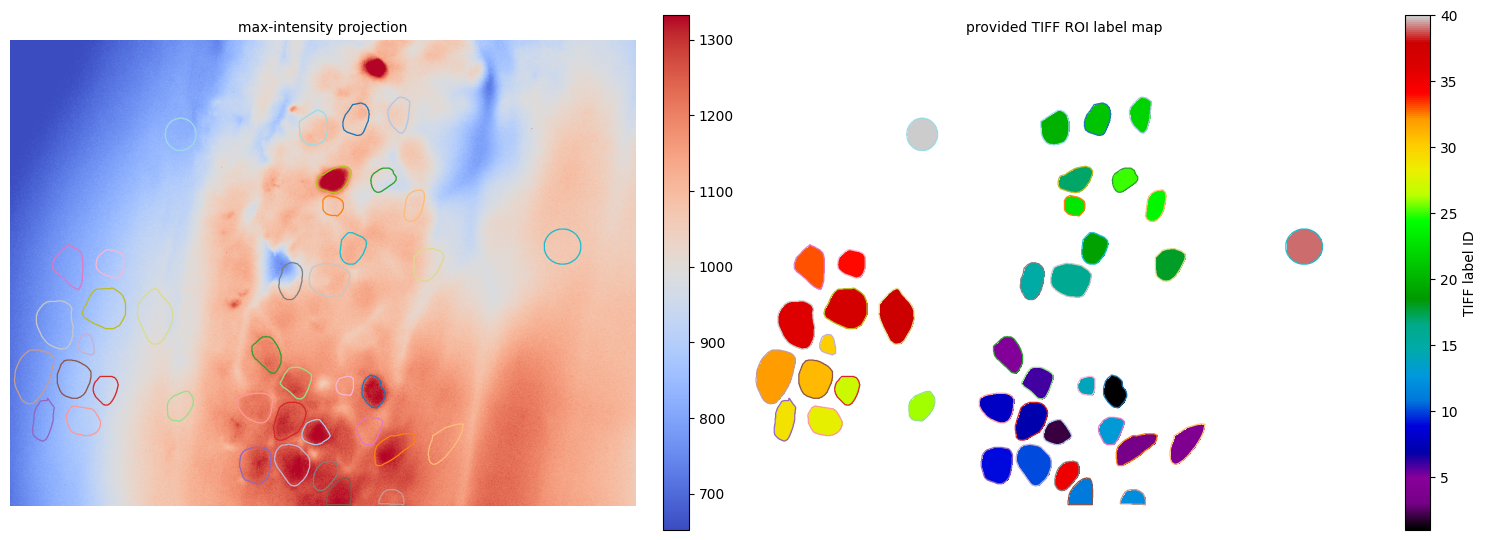

In [64]:
def compute_max_projection(index: pl.DataFrame = file_index,
                           cache_path: Path = CACHE_DIR / f"max_projection_ch{CHANNEL}_full.npy",
                           force_recompute: bool = False) -> np.ndarray:
    if cache_path.exists() and not force_recompute:
        return np.load(cache_path)

    max_proj = None
    for path in tqdm(index["image_path"], total=index.height, desc="max projection"):
        frame = np.load(path).squeeze(axis=0)
        max_proj = frame.copy() if max_proj is None else np.maximum(max_proj, frame)

    np.save(cache_path, max_proj)
    return max_proj


max_proj = compute_max_projection()
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
colors = plt.cm.tab20.colors

vmin, vmax = np.percentile(max_proj, [2, 99.5])
im = axes[0].imshow(max_proj, cmap="coolwarm", vmin=vmin, vmax=vmax)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
axes[0].set_title("max-intensity projection", fontsize=10)

if ROI_SOURCE == "tiff":
    roi_map = np.ma.masked_where(tiff_label_map == 0, tiff_label_map)
    im = axes[1].imshow(roi_map, cmap="nipy_spectral", interpolation="nearest",
                        vmin=1, vmax=max(TIFF_LABEL_IDS))
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="TIFF label ID")
    axes[1].set_title("provided TIFF ROI label map", fontsize=10)
else:
    roi_map = activity["snr"]
    vmin, vmax = np.percentile(roi_map, [2, 99.5])
    im = axes[1].imshow(roi_map, cmap="coolwarm", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04,
                 label="structured SNR")
    axes[1].set_title("automatic-detection activity map", fontsize=10)

for ax in axes:
    for i, mask in enumerate(roi_masks):
        ax.contour(mask, levels=[0.5], colors=[colors[i % len(colors)]], linewidths=0.9)
    ax.axis("off")
fig.tight_layout()
plt.show()


## 11. Exported artifacts

Expensive computations and inferred traces are cached under `analysis_cache/`:

| File | Contents |
|---|---|
| `frame_stats_ch<CHANNEL>.parquet` | per-frame summary statistics and timestamps |
| `activity_map_ch<CHANNEL>_<preprocessing>.npz` | automatic-detection maps; created only if automatic ROI selection is used |
| `roi_traces_ch<CHANNEL>_<source>_n<N>_<hash>.parquet` | denoised F, baseline, dF/F, and (after §9.5) DS40 CASCADE columns for the active masks |
| `cascade_input_<source>_<hash>.npz` | fractional denoised dF/F and native timestamps sent to the bridge |
| `cascade_ds40_<source>_<hash>.npz` | 30 Hz DS40 predictions, native-bin expected spikes/rates, and noise-model choices |
| `max_projection_ch<CHANNEL>_full.npy` | pixel-wise max over the recording |

The TIFF masks remain in `_labels/Debi_DRG_ROI.tiff`; automatic masks are reproduced
from their cached activity map and threshold settings. The mask-pixel hash prevents a
trace cache from being reused after the ROI set changes.
